<a href="https://colab.research.google.com/github/ramakant-BIM/JSW-Projects/blob/main/Packaging_ML_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

df = pd.read_excel("Packaging_ML_Data.xlsx")

X = df[
[
'Shelf_Visibility',
'Premium_Perception',
'Product_Clarity',
'SKU_Clarity',
'Dealer_Recommendation',
'Contractor_Recognition',
'Modernity',
'Claim_Clarity',
'Purchase_Intent'
]
]

y = df['Packaging_Effectiveness_Score']

X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

model = RandomForestRegressor(
n_estimators=200,
max_depth=6,
random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("R² Score:", r2_score(y_test,predictions))

R² Score: -0.10816067431114473


# New Section

### Actual vs. Predicted Scores Plot
Let's visualize the actual vs. predicted scores to understand the model's performance on the test set. A perfect model would have all points lying on the diagonal line.

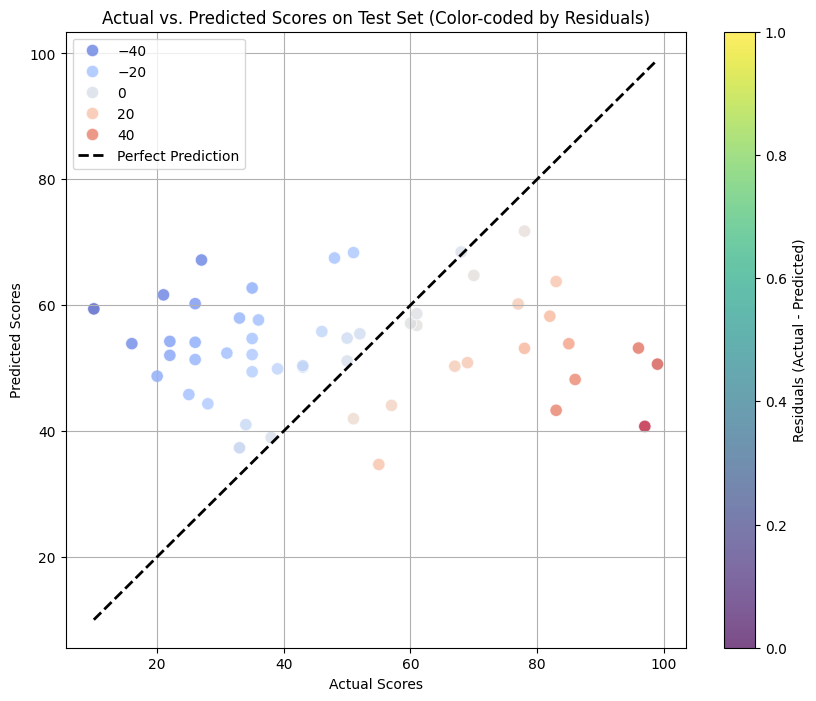

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals (difference between actual and predicted)
residuals = y_test - predictions

plt.figure(figsize=(10, 8))
# Use 'hue' to color-code points based on residuals
scatter = sns.scatterplot(x=y_test, y=predictions, hue=residuals, palette='coolwarm', alpha=0.7, s=80)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction') # Changed to black dashed line
plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.title('Actual vs. Predicted Scores on Test Set (Color-coded by Residuals)')
plt.legend()
plt.grid(True)
plt.colorbar(scatter.collections[0], label='Residuals (Actual - Predicted)') # Pass the mappable from the scatter plot
plt.show()

##Random Forest Model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

rf.fit(X_train,y_train)

pred = rf.predict(X_test)

print("R2 Score =",r2_score(y_test,pred))

R2 Score = -0.14378454966646737


##Feature Importance

In [ ]:
features = X.columns.tolist()
importance = pd.DataFrame({
    'Feature':features,
    'Importance':rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                  Feature  Importance
2         Product_Clarity    0.147849
3             SKU_Clarity    0.136208
8         Purchase_Intent    0.131582
0        Shelf_Visibility    0.114845
1      Premium_Perception    0.104631
5  Contractor_Recognition    0.095394
4   Dealer_Recommendation    0.093219
7           Claim_Clarity    0.091811
6               Modernity    0.084461


/tmp/ipykernel_7910/3028915589.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')


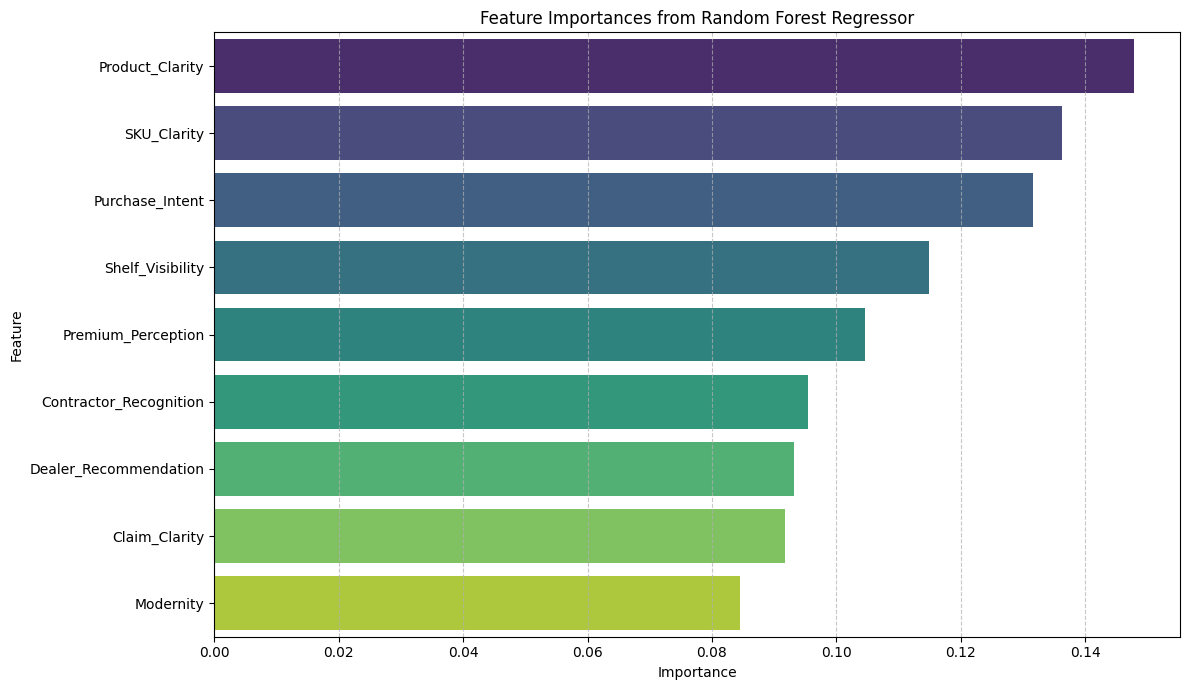

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')
plt.title('Feature Importances from Random Forest Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##Packaging Simulator

In [ ]:
new_pack = pd.DataFrame({
'Shelf_Visibility':[9],
'Premium_Perception':[8],
'Product_Clarity':[8],
'SKU_Clarity':[8],
'Claim_Clarity':[8],
'Dealer_Recommendation':[9],
'Contractor_Recognition':[8],
'Modernity':[8],
'Purchase_Intent':[8]
})

# Reorder columns to match the order used during model training
# The 'features' variable holds the correct order from X.columns.tolist()
new_pack = new_pack[features]

prediction = rf.predict(new_pack)

print(
f"Predicted Packaging Score = {prediction[0]:.2f}"
)

Predicted Packaging Score = 69.05
